C:\Users\xan37\AppData\Local\Temp\ipykernel_10424\290075418.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, '3V Model')

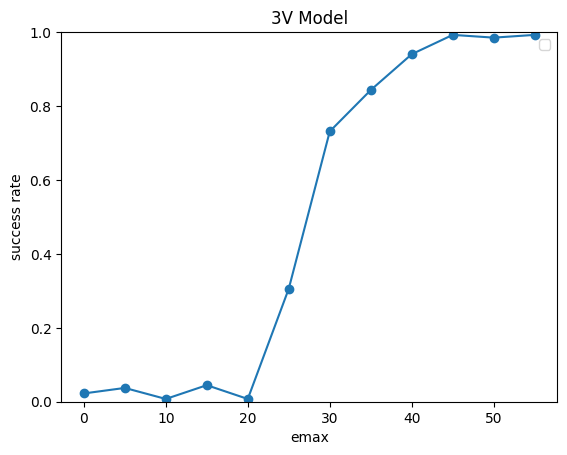

In [69]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict
data2 = {}
dt = 0.5

with open('FTE_result.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_Emax(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else None for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            data2[i_idx][j_idx] = values
success_rate = defaultdict(lambda: defaultdict(float))
for E_max_idx in sorted(data2[1].keys()):
    for IC_idx in data2.keys():
        if len(data2[IC_idx][E_max_idx]) <= 250/dt:
                success_rate[E_max_idx][IC_idx] += 1.0 / (      len(data2.keys())        )

plt.plot(sorted(success_rate.keys()), [sum([i for i in success_rate[e_idx].values()]) for e_idx in sorted(success_rate.keys())],'-o')
plt.ylim(0,1)
plt.legend()
plt.xlabel('emax')
plt.ylabel('success rate')
plt.savefig('success_rate_vs_emax_etimeact.png')
plt.title('3V Model')

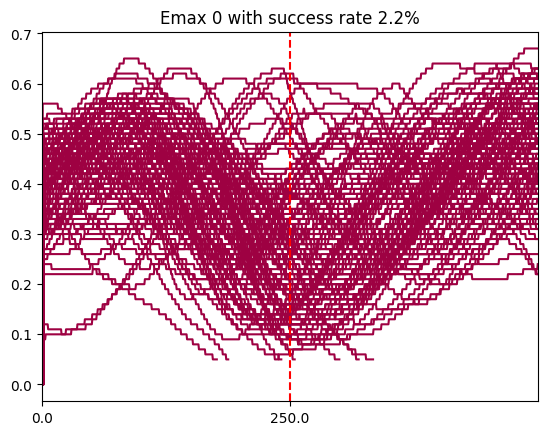

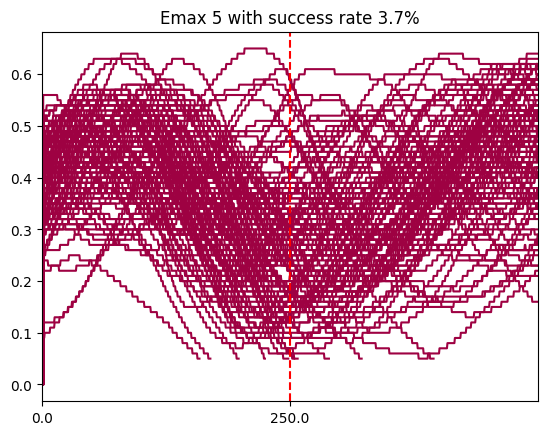

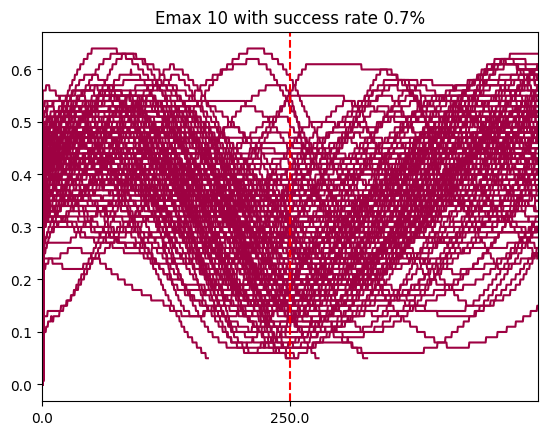

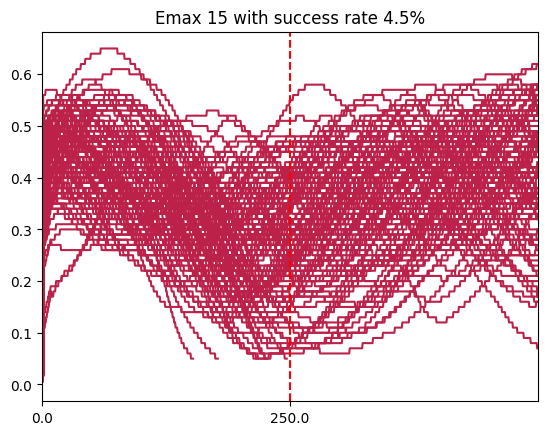

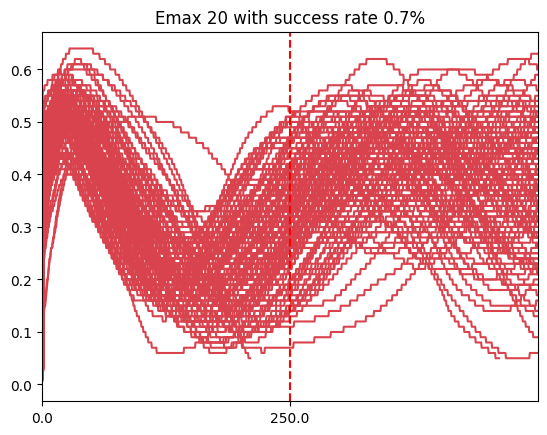

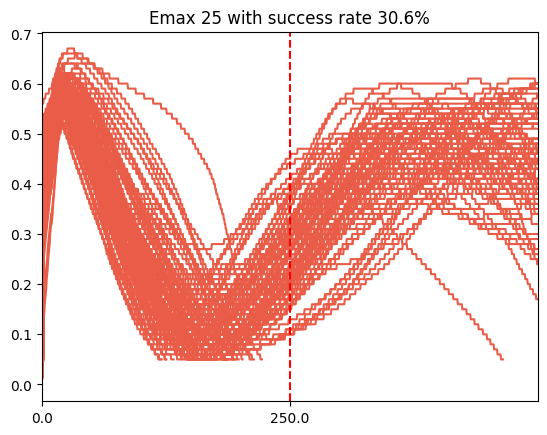

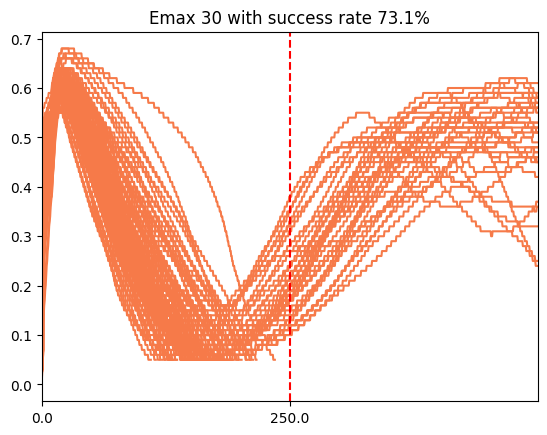

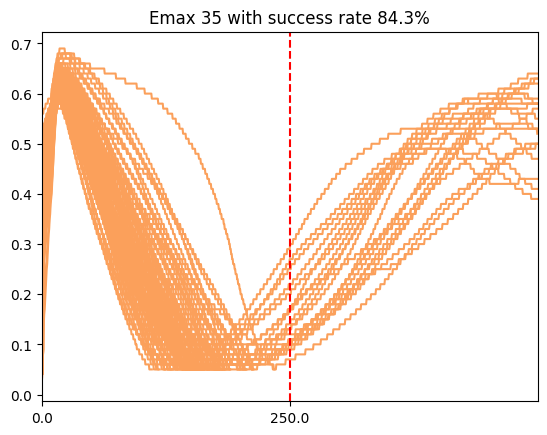

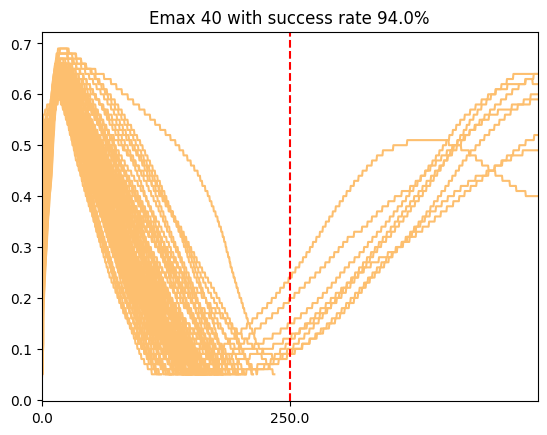

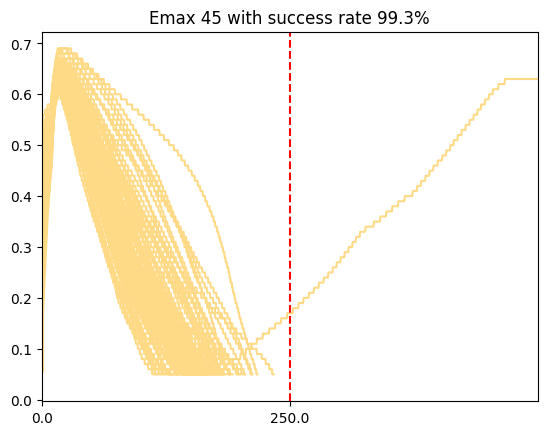

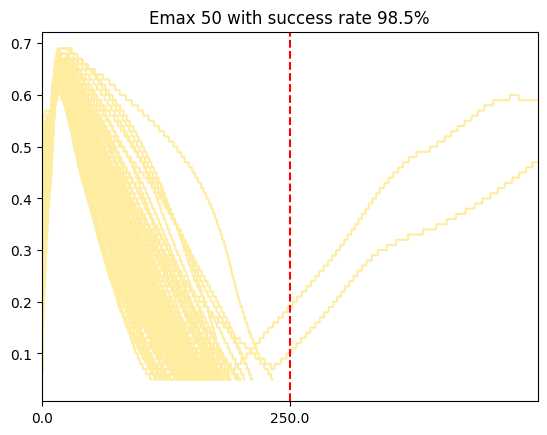

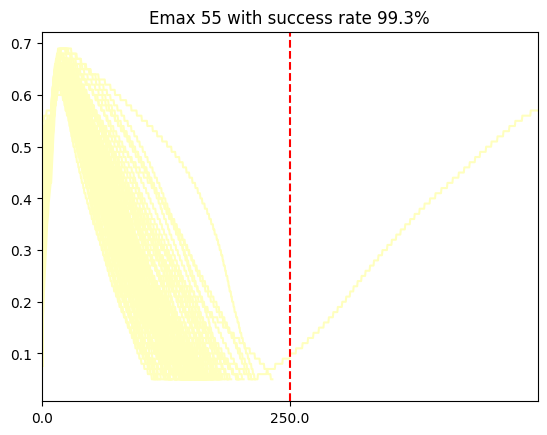

In [70]:
dt = 0.5
# make color based on Emax (Emax 20,60,100)
def get_color_gradient(val, vmin=10, vmax=100):
    # 1. Normalize the value to a 0.0 - 1.0 range
    normalized = (val - vmin) / (vmax - vmin)
    
    # 2. Get the color from a colormap (e.g., 'plasma', 'viridis', 'inferno')
    colormap = plt.get_cmap('Spectral')
    return colormap(normalized)

success_rate = defaultdict(lambda: defaultdict(float))
for E_max_idx in sorted(data2[1].keys()):
    plt.figure()
    for IC_idx in data2.keys():            
        if len(data2[IC_idx][E_max_idx]) <= 250/dt:
            success_rate[E_max_idx][IC_idx] += 1.0 / (len(data2.keys()))
        plt.plot(data2[IC_idx][E_max_idx],color = get_color_gradient(E_max_idx))
        # make sure x range from 0 to 4000
        plt.xlim(0,1000)
        # also make x tick *= 0.5
        plt.xticks(ticks=range(0,1000,500), labels=[str(x*0.5) for x in range(0,1000,500)])
    plt.title(f'Emax {E_max_idx} with success rate {sum([i for i in success_rate[E_max_idx].values()])*100:.1f}%')

    # plot the success rate metric as a vertical line
    plt.axvline(x=250/dt, color='r', linestyle='--', label='Success Threshold (500s)')